# Import packages needed for running code

In [467]:
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
from scipy.stats import poisson
import pandas as pd
import random as rd
import itertools as it

# Define model's parameters

In [468]:
M = 5  # max. shelf life
mu = 3  # mean demand of Poisson distribution
Dmx = 3 * mu  # trunacte demand ceiling; you cannot realistically sell more
prob = pmf_values = poisson.pmf(np.arange(0, Dmx + 1), mu)
prob[Dmx] = 1 - prob[0:Dmx].sum()

z = 1 / sqrt(mu)  # for 1 day of safety stock set z = 1/sqrt(2)

# Dmx is the practical upperbound and 2 * mu + z * sqrt(2) * mu
# is a statistical motivated amount. Choose the lowest as the maximum
# number of items on the shelf per item age.
UBI = min(Dmx, 2 * mu + z * sqrt(2) * mu)  # Upperbound on \# items in each age class

r = 250  # regular sales price (excl. discount)
c = 175  # purchase price

Tw = 10  # warmin up period of simulation (is excluded in calculating statistics)
T = Tw + 36500  # length of a simulation (episode length).

# Reserve memory for variables

In [469]:
def initialize():
    # (this prevents high RAM use until Garbage collection)
    I = np.empty([T + 1, M], dtype=int)
    IL = np.empty([T, M], dtype=int)
    BSPlvl = np.empty(T, dtype=int)
    Order = np.empty(T, dtype=int)
    D = np.empty(T, dtype=int)
    DF = np.empty(T, dtype=int)
    DL = np.empty(T, dtype=int)
    DeltaF = np.empty([T, M], dtype=int)
    DeltaL = np.empty([T, M], dtype=int)
    SALES = np.empty(T, dtype=int)
    PRF = np.empty(T)
    LS = np.empty(T, dtype=int)
    WST = np.empty(T, dtype=int)
    Profit = np.zeros(11)
    return I, IL, BSPlvl, Order, D, DF, DL, DeltaF, DeltaL, SALES, PRF, LS, WST, Profit

# Optional functions to make states into string

In [470]:
def State2Index(I):
    idx = I[0]
    for i in range(1, M):
        idx = (1 + UBI) * idx + I[i]
    return idx


def Index2State(idx):
    Ilist = []
    for i in range(M):
        idx1 = int(idx / (1 + UBI))
        Ilist.append(idx - idx1 * (1 + UBI))
        print(idx, idx1, Ilist)
        idx = idx1
    return np.array(Ilist.reverse())

# Define state space, probabilities, action space and reward space

In [471]:
BSPlvl = round(2 * mu + z * sqrt(2) * mu)
S = np.arange(BSPlvl + 1)
SS = np.array(list(it.product(S, repeat = M)))

valid = SS.sum(axis=1) <= BSPlvl
SS = SS[valid]
nS = len(SS)
s1 = np.zeros(M)

AA = np.arange(11)
nA = len(AA)

RR = np.zeros([nA, nS])
PP = np.zeros([nA, nS, nS]) # Changed nS1 to nS for the third dimension

# Run the model for each action.
<ol>
  <li>Action: a discount on the oldest product.</li>
  <li>Reward: LEFO + FEFO - order costs</li>
  <li>State: combination of number of items per product age per day</li>
  <li>Probability: poisson model distribution around mu = 3</li>
</ol>





In [472]:
for ida, a in enumerate(AA): # action: discount
    rd.seed(1)
    np.random.seed(1)
    IL = np.zeros(M, dtype=int)
    Order = np.zeros(1, dtype=int)
    DF = np.zeros(1, dtype=int)
    DL = np.zeros(1, dtype=int)
    DeltaF = np.zeros(M, dtype=int)
    DeltaL = np.zeros(M, dtype=int)
    SALES = np.zeros(1, dtype=int)
    PRF = np.zeros(1,dtype = float)
    LS = np.zeros(1, dtype=int)
    WST = np.zeros(1, dtype=int)

    for ids, s in enumerate(SS): # state: inventory
        # discount
        aa = 0.05 * a

        # set order quantity:
        Order = max(0, BSPlvl_temp - s.sum())
        PRF = np.zeros(1,dtype = float)

        for idd, d in enumerate(range(Dmx + 1)): # demand
            # split demand
            DF_frac = min(s[M - 1], aa * d)
            DF_int = int(DF_frac)
            DF = DF_int
            if DF_frac != DF_int:  # stochastic rounding
                Frac = DF_frac - DF_int
                u = rd.random()
                if u < Frac:
                    DF = DF_int + 1
            DL = d - DF

            # pick FEFO demand:
            DeltaF[M - 1] = DF  # only oldest are discounted (<= max I[t,M-1])
            # available for LEFO customers/adjust stock levels:
            IL = s - DeltaF
            # pick LEFO demand:
            DeltaL[0] = min(DL, IL[0])  # youngest first
            for i in range(1, M):
                DeltaL[i] = min(DL - DeltaL[0:i].sum(), IL[i])

            # adjust stock levels:
            s1[:] = IL - DeltaL
            WST = s1[M - 1]
            s1[:] = np.roll(s1, 1)
            s1[0] = Order  # as lead time is one period
            # more stats:
            LS = max(0, d - s.sum())
            SALES = DeltaF + DeltaL

            p = prob[idd]
            PRF += p * (r * DeltaL.sum() + r * (1 - aa) * DeltaF.sum() - c * Order)

            ids1 = np.where((SS == s1).all(axis = 1))[0][0].item()
            PP[ida,ids,ids1] += p
        RR[ida, ids] += PRF[0].item()


# Check how many states per action are possible

In [473]:
def check_states(PP, nA):
    print(f"Total number of states (second dimension): {PP.shape[1]}")
    for i in range(nA):
        count = 0
        for j in range(PP.shape[1]):  # use PP.shape[1] instead of nS to adapt dynamically
            if PP[i, j, :].sum() == 1.0:
                count += 1
        print(f'Action {i} has {count} possible states.')


In [474]:
# before removal
print("Before removal: \n")
check_states(PP, nA)

Before removal: 

Total number of states (second dimension): 1287
Action 0 has 1051 possible states.
Action 1 has 1056 possible states.
Action 2 has 1062 possible states.
Action 3 has 1061 possible states.
Action 4 has 1072 possible states.
Action 5 has 1085 possible states.
Action 6 has 1093 possible states.
Action 7 has 1093 possible states.
Action 8 has 1075 possible states.
Action 9 has 1073 possible states.
Action 10 has 1062 possible states.


Remove nonexisting states

In [475]:
mask = PP.sum(axis=2).sum(axis=0) == 0  # shape: (1287,) — True where sum is 0

# Delete all matching indices at once
SS_copy = SS[~mask]  # remove the same zero-entries from SS
PP_copy = np.delete(PP.copy(), np.where(mask)[0], axis=1)

In [476]:
print(f"Removed {mask.sum()} zero states\n")
print(f"SS size: {len(SS_copy)}, PP axis 1 size: {PP_copy.shape[1]}")  # should be equal

Removed 0 zero states

SS size: 1287, PP axis 1 size: 1287


And check the possible states again - they should not have changed

In [477]:
# after removal
print("After removal: \n")
check_states(PP_copy, nA)

After removal: 

Total number of states (second dimension): 1287
Action 0 has 1051 possible states.
Action 1 has 1056 possible states.
Action 2 has 1062 possible states.
Action 3 has 1061 possible states.
Action 4 has 1072 possible states.
Action 5 has 1085 possible states.
Action 6 has 1093 possible states.
Action 7 has 1093 possible states.
Action 8 has 1075 possible states.
Action 9 has 1073 possible states.
Action 10 has 1062 possible states.


# Use Iterative Policy Evaluation with Policy Improvement.

In [482]:
pi = np.random.randint(0, 9, size = nS)
V = np.zeros(len(SS))
V_prev = np.zeros(len(SS))
q = np.zeros([nA, len(SS)])
gamma = 0.999999
PolicyNotStable = True
niterPI = 0

while PolicyNotStable:
    niterPI += 1

    # Iterative Policy evaluation
    niterIPE = 0
    theta = 0.0001 * (1 - gamma) / (2 * gamma)
    span = 1 + theta
    while span > theta:
        niterIPE += 1
        for ids, s in enumerate(SS):
            a = pi[ids]
            ida = np.where(AA == a)[0][0]  # look up the action index associated with action a
            V[ids] = RR[ida, ids] + gamma * PP[ida, ids, :] @ V_prev

        Diff = V - V_prev
        span = max(Diff) - min(Diff)
        V_prev = V.copy()  # create a copy of the content of V, rather than copy the reference to V
        niterIPE += 1

    print(niterPI, niterIPE, pi)

    # POLICY IMPROVEMENT
    pi_prev = pi.copy()
    PolicyNotStable = False
    for ids, s in enumerate(SS):
        qbest = - np.inf
        for ida, a in enumerate(AA):
            q[ida, ids] = RR[ida, ids] + gamma * PP[ida, ids, :] @ V_prev
            if q[ida, ids] > qbest:
                pi[ids] = a
                qbest = q[ida, ids]
        if pi[ids] != pi_prev[ids]:
            PolicyNotStable = True




1 212 [5 1 4 ... 2 1 5]
2 188 [0 0 0 ... 0 0 0]
3 152 [0 0 0 ... 0 0 0]
4 106 [0 0 0 ... 0 0 0]


# Look into the contents of the final policy

In [479]:
val_d = {}
for i in pi:
    if i in val_d:
        val_d[i] += 1
    else:
        val_d[i] = 1

In [483]:
for key in val_d:
    print(f'{key} : {val_d[key]}')

0 : 548
1 : 52
2 : 86
3 : 164
4 : 174
7 : 35
5 : 145
8 : 17
6 : 63
9 : 3


# Reference
## Code



In [363]:
I, IL, BSPlvl, Order, D, DF, DL, DeltaF, DeltaL, SALES, PRF, LS, WST, Profit = initialize()
for aa in range(11):   #LOOP OVER DISCOUNT PERCENTAGES
  # RE-INITIALIZE variables and rand seeds
    rd.seed(1)
    np.random.seed(1)
    I[:] = np.zeros([T+1, M], dtype=int)
    IL[:] = np.zeros([T, M], dtype=int)
    BSPlvl[:]  = np.zeros(T, dtype=int)
    Order[:]  = np.zeros(T, dtype=int)
    D[:]  = np.zeros(T, dtype=int)
    DF[:]  = np.zeros(T, dtype=int)
    DL[:]  = np.zeros(T, dtype=int)
    DeltaF[:] = np.zeros([T, M], dtype=int)
    DeltaL[:] = np.zeros([T, M], dtype=int)
    SALES[:]  = np.zeros(T, dtype=int)
    PRF[:]  = np.zeros(T)
    LS[:]  = np.zeros(T, dtype=int)
    WST[:]  = np.zeros(T, dtype=int)

  # SIMULATE INVENTORY DYANMICS OVER ALL PERIODS
    for t in range(T):
        # observe state
        if t<0:
            print(I[t], State2Index(I[t]))
        # predict demand and set BSP level
        BSPlvl[t] = round(2*mu + z * sqrt(2)*mu)
        # set discount
        a = 0.05 *aa
        # set order quantity:
        Order[t] = max(0, BSPlvl[t] - I[t].sum())
        # set demand:
        D[t] = min( Dmx, np.random.poisson(mu) )
        # split demand
        DF_frac = min(I[t,M-1], a * D[t] )
        DF_int = int(DF_frac)
        DF[t] = DF_int
        if DF_frac != DF_int: # stochastic rounding
            Frac = DF_frac - DF_int
            u = rd.random()
            if u < Frac:
                DF[t] = DF_int + 1
        DL[t] = D[t] - DF[t]

        # pick FEFO demand:
        DeltaF[t,M-1] = DF[t]  # only oldest are discounted (<= max I[t,M-1])
        # available for LEFO customers/adjust stock levels:
        IL[t] = I[t] - DeltaF[t]
        # pick LEFO demand:
        DeltaL[t,0] = min(DL[t], IL[t,0])   # youngest first
        for i in range(1,M):
            DeltaL[t,i] = min(DL[t] - DeltaL[t,0:i].sum() , IL[t,i])

        # adjust stock levels:
        I[t+1,:] = IL[t] - DeltaL[t]
        WST[t] = I[t+1, M-1]
        I[t+1,:] = np.roll(I[t+1],1)
        I[t+1,0] = Order[t]   # as lead time is one period
        # more stats:
        LS[t] = max( 0, D[t] - I[t].sum() )
        SALES[t] = DeltaF[t].sum() + DeltaF[t].sum()
        PRF[t] = r * DeltaL[t].sum() + r * (1-a) * DeltaF[t].sum() - c * Order[t]

  # COMPUTE & PRINT AVERAGES OF KEY PERFORMANCE MEASURES
    WasteRel = WST[Tw:T].mean() / Order[Tw:T].mean()
    Fillrate = 1 - LS[Tw:T].mean() / D[Tw:T].mean()
    Profit[aa] = PRF[Tw:T].mean()
    print(f"Discount = {a * 100:.0f}%, Profit = {Profit[aa]:.3f}, Waste = {WasteRel*100:.1f} %, Fillrate = {Fillrate*100:.1f} %")


Discount = 0%, Profit = 170.193, Waste = 6.9 %, Fillrate = 91.6 %
Discount = 5%, Profit = 171.984, Waste = 6.5 %, Fillrate = 91.7 %
Discount = 10%, Profit = 173.010, Waste = 6.2 %, Fillrate = 91.9 %
Discount = 15%, Profit = 173.747, Waste = 5.8 %, Fillrate = 92.0 %
Discount = 20%, Profit = 173.529, Waste = 5.4 %, Fillrate = 92.1 %
Discount = 25%, Profit = 172.982, Waste = 5.0 %, Fillrate = 92.2 %
Discount = 30%, Profit = 171.703, Waste = 4.7 %, Fillrate = 92.3 %
Discount = 35%, Profit = 170.147, Waste = 4.3 %, Fillrate = 92.4 %
Discount = 40%, Profit = 168.120, Waste = 4.0 %, Fillrate = 92.5 %
Discount = 45%, Profit = 165.780, Waste = 3.7 %, Fillrate = 92.5 %
Discount = 50%, Profit = 163.126, Waste = 3.4 %, Fillrate = 92.6 %


## Plot out the baseline figure

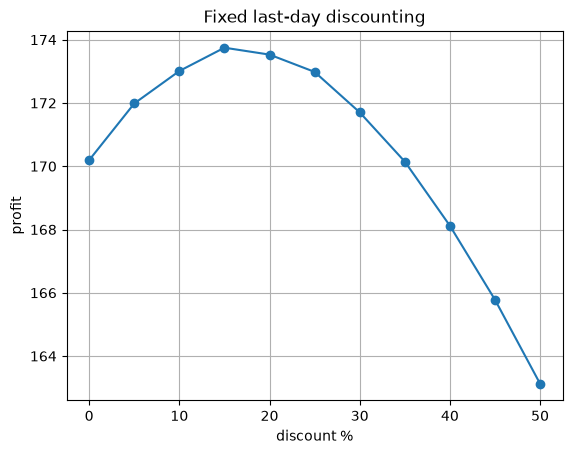

                 I  BSPlvl  Order  D            Delta  LS  Wst     Prf
0  [0, 0, 0, 0, 0]       8      8  2  [0, 0, 0, 0, 0]   2    0 -1400.0
1  [8, 0, 0, 0, 0]       8      0  1  [0, 0, 0, 0, 0]   0    0   250.0
2  [0, 7, 0, 0, 0]       8      1  1  [0, 0, 0, 0, 0]   0    0    75.0
3  [1, 0, 6, 0, 0]       8      1  3  [0, 0, 0, 0, 0]   0    0   575.0
4  [1, 0, 0, 4, 0]       8      3  3  [0, 0, 0, 0, 0]   0    0   225.0
5  [3, 0, 0, 0, 2]       8      3  3  [0, 0, 0, 0, 4]   0    0   -25.0
6  [3, 2, 0, 0, 0]       8      3  3  [0, 0, 0, 0, 0]   0    0   225.0
7  [3, 0, 2, 0, 0]       8      3  3  [0, 0, 0, 0, 0]   0    0   225.0
8  [3, 0, 0, 2, 0]       8      3  0  [0, 0, 0, 0, 0]   0    0  -525.0
9  [3, 3, 0, 0, 2]       8      0  2  [0, 0, 0, 0, 2]   0    1   375.0
                     I  BSPlvl  Order  D            Delta  LS  Wst    Prf
36500  [4, 0, 0, 0, 1]       8      3  2  [0, 0, 0, 0, 2]   0    0 -150.0
36501  [3, 3, 0, 0, 0]       8      2  3  [0, 0, 0, 0, 0]   0    0  400

In [364]:
plt.plot(5 * np.arange(11), Profit, marker='o')  # Line plot with points
plt.title("Fixed last-day discounting")
plt.xlabel("discount %")
plt.ylabel("profit")
plt.grid(True)
plt.show()

# plt.plot(D)
# plt.show()
# plt.plot(LS)
# plt.show()

df = pd.DataFrame(
    {'I': list(I[0:T]) ,
     'BSPlvl': BSPlvl,
     'Order': Order,
     'D': D,
     'Delta': list(DeltaF + DeltaF),
     'LS': LS,
     'Wst': WST,
     'Prf': PRF
     })

print(df.head(10))
print(df.tail(10))


# Run the policy on the model

In [484]:
I, IL, BSPlvl, Order, D, DF, DL, DeltaF, DeltaL, SALES, PRF, LS, WST, Profit = initialize()

rd.seed(1)
np.random.seed(1)
I[:] = np.zeros([T + 1, M], dtype=int)
IL[:] = np.zeros([T, M], dtype=int)
BSPlvl[:] = np.zeros(T, dtype=int)
Order[:] = np.zeros(T, dtype=int)
D[:] = np.zeros(T, dtype=int)
DF[:] = np.zeros(T, dtype=int)
DL[:] = np.zeros(T, dtype=int)
DeltaF[:] = np.zeros([T, M], dtype=int)
DeltaL[:] = np.zeros([T, M], dtype=int)
SALES[:] = np.zeros(T, dtype=int)
PRF[:] = np.zeros(T)
LS[:] = np.zeros(T, dtype=int)
WST[:] = np.zeros(T, dtype=int)

# SIMULATE INVENTORY DYANMICS OVER ALL PERIODS
for t in range(T):

    # predict demand and set BSP level
    BSPlvl[t] = round(2 * mu + z * sqrt(2) * mu)

    # set discount
    pi_a_idx = np.where((SS == I[t]).all(axis = 1))[0][0].item()
    a = 0.05 * pi[pi_a_idx]

    # set order quantity:
    Order[t] = max(0, BSPlvl[t] - I[t].sum())

    # set demand:
    D[t] = min(Dmx, np.random.poisson(mu))

    # split demand
    DF_frac = min(I[t, M - 1], a * D[t])
    DF_int = int(DF_frac)
    DF[t] = DF_int
    if DF_frac != DF_int:  # stochastic rounding
        Frac = DF_frac - DF_int
        u = rd.random()
        if u < Frac:
            DF[t] = DF_int + 1
    DL[t] = D[t] - DF[t]

    # pick FEFO demand:
    DeltaF[t, M - 1] = DF[t]  # only oldest are discounted (<= max I[t,M-1])

    # available for LEFO customers/adjust stock levels:
    IL[t] = I[t] - DeltaF[t]

    # pick LEFO demand:
    DeltaL[t, 0] = min(DL[t], IL[t, 0])  # youngest first
    for i in range(1, M):
        DeltaL[t, i] = min(DL[t] - DeltaL[t, 0:i].sum(), IL[t, i])

    # adjust stock levels:
    I[t + 1, :] = IL[t] - DeltaL[t]
    WST[t] = I[t + 1, M - 1]
    I[t + 1, :] = np.roll(I[t + 1], 1)
    I[t + 1, 0] = Order[t]  # as lead time is one period

    # more stats:
    LS[t] = max(0, D[t] - I[t].sum())
    SALES[t] = DeltaF[t].sum() + DeltaL[t].sum()
    PRF[t] = r * DeltaL[t].sum() + r * (1 - a) * DeltaF[t].sum() - c * Order[t]

WasteRel = WST[Tw:T].mean() / Order[Tw:T].mean()
Fillrate = 1 - LS[Tw:T].mean() / D[Tw:T].mean()
Profit = PRF[Tw:T].mean()
print(f"Profit = {Profit:.3f}, Waste = {WasteRel * 100:.1f} %, Fillrate = {Fillrate * 100:.1f} %")

Profit = 173.916, Waste = 5.6 %, Fillrate = 92.1 %
